<a href="https://colab.research.google.com/github/vijayteja-N/3-body-orbit-simulation/blob/main/SIMULATION%20NOTEBOOK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulating Two body Orbit using LeapFrog's methods
## Asuumptions
*   1. Assume Sun is at center and earth is revolving around sun
    2. Consider GM = 1 (M= mass of sun,G= Gravitational constant)
    3. mass of earth = m =1
    4. initial position of earth= r = (1,0)

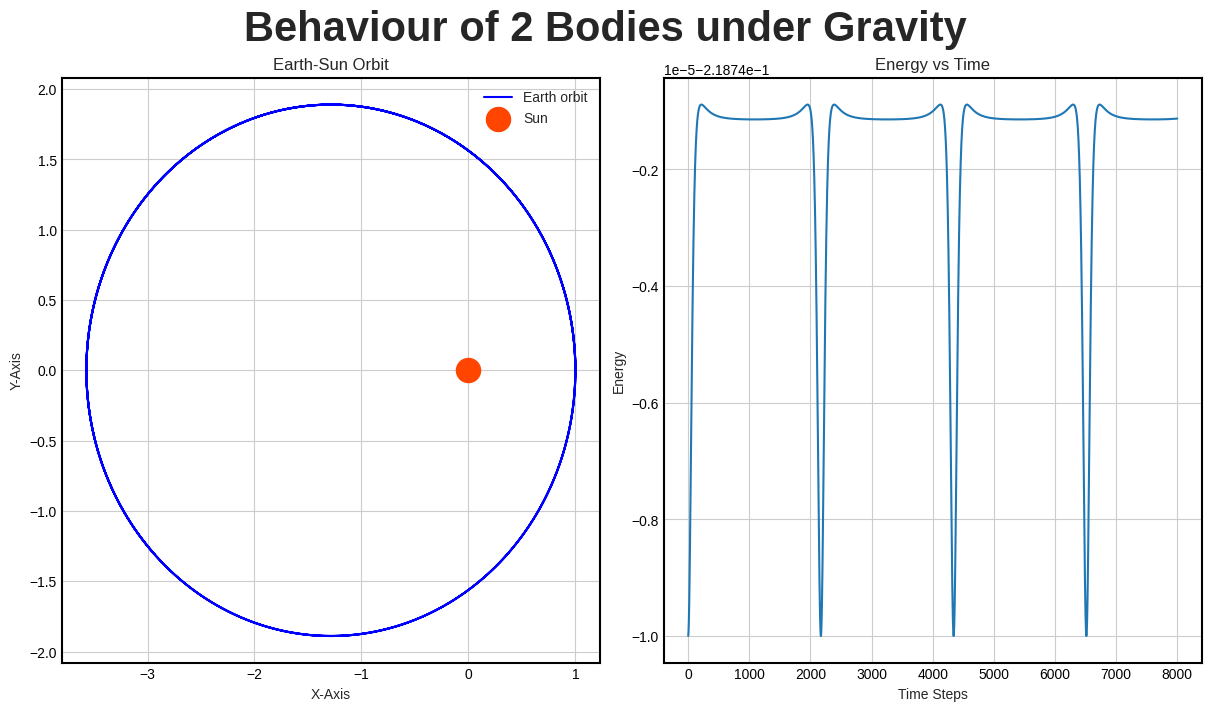

In [8]:
import numpy as np
import matplotlib.pyplot as plt


# Initial conditions
r = np.array([1.00,0.00])


v = np.array([0.00,1.250])

def acceleration(r):
    r_mag = np.linalg.norm(r)
    return -r/r_mag**3

positions = []

energies =   []

a =  acceleration(r)

#LeapFrog's methods

dt = 0.01
N = 8000

for w in range(N):

    v_halfstep = v + 0.5 * dt * a

    r = r + dt*v_halfstep

    a_new = acceleration(r)

    v = v_halfstep + 0.5 * dt * a_new

    a = a_new

    positions.append(r.copy())
    energy = (0.5 * np.dot(v,v)) - 1/np.linalg.norm(r)
    energies.append(energy.copy())

positions = np.array(positions)
energies = np.array(energies)

## Plotting
plt.style.use( 'seaborn-v0_8-whitegrid')


fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,7),constrained_layout=True)

ax[0].plot(positions[:,0],positions[:,1],color='blue',label='Earth orbit');

ax[0].set(title='Earth-Sun Orbit',xlabel='X-Axis',ylabel='Y-Axis');

ax[0].scatter(0, 0,color='orangered',s=300,label='Sun',zorder=3);

ax[0].legend()

for spine in ax[0].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)

ax[0].tick_params(colors='#000000', width=1.2)

ax[1].plot(energies)
ax[1].set(title='Energy vs Time',xlabel='Time Steps',ylabel='Energy');
fig.suptitle('Behaviour of 2 Bodies under Gravity', fontsize=30, fontweight='bold')
for spine in ax[1].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
ax[1].tick_params(colors='#000000', width=1.2)






# Behavior of Sun and Earth with real data


## Case 1 using equations of circular motion

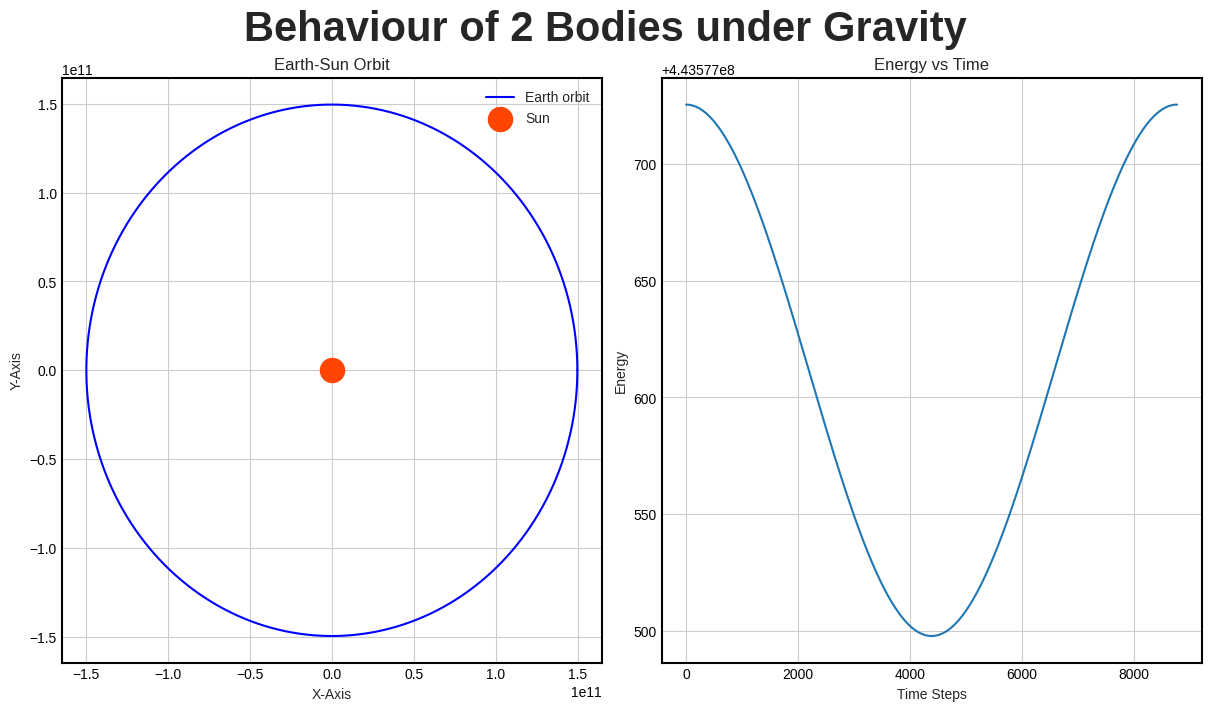

In [9]:
# Initial conditions
G = 6.67430e-11        # m^3 kg^-1 s^-2
M_sun = 1.9885e30     # kg


#Mean Orbital Radius of earth-sun system
r0 = 1.496e11   # meters
r = np.array([r0,0.00])

# Earth's Orbital velocity
v0 = np.sqrt(G * M_sun / r0)
v = np.array([0.00,v0]) #meters/sec

def acceleration(r):
    r_mag = np.linalg.norm(r)
    return -G * M_sun * r / r_mag**3


positions = []

energies =   []

a =  acceleration(r)

#LeapFrog's methods

dt = 3600 # (1 Hour= 3600 sec)
N = int(365.25 * 24)   # hours in one year


for w in range(N):

    v_halfstep = v + 0.5 * dt * a

    r = r + dt*v_halfstep

    a_new = acceleration(r)

    v = v_halfstep + 0.5 * dt * a_new

    a = a_new

    positions.append(r.copy())
    energy = (0.5 * np.dot(v,v)) - 1/np.linalg.norm(r)
    energies.append(energy.copy())

positions = np.array(positions)
energies = np.array(energies)

## Plotting
plt.style.use( 'seaborn-v0_8-whitegrid')


fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,7),constrained_layout=True)

ax[0].plot(positions[:,0],positions[:,1],color='blue',label='Earth orbit');

ax[0].set(title='Earth-Sun Orbit',xlabel='X-Axis',ylabel='Y-Axis');

ax[0].scatter(0, 0,color='orangered',s=300,label='Sun',zorder=3);

ax[0].legend()

for spine in ax[0].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)

ax[0].tick_params(colors='#000000', width=1.2)

ax[1].plot(energies)
ax[1].set(title='Energy vs Time',xlabel='Time Steps',ylabel='Energy');
fig.suptitle('Behaviour of 2 Bodies under Gravity', fontsize=30, fontweight='bold')
for spine in ax[1].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
ax[1].tick_params(colors='#000000', width=1.2)










## Case 2: Real Earth's orbit, eccentricity = 0.0167
* assume starts at perihelion

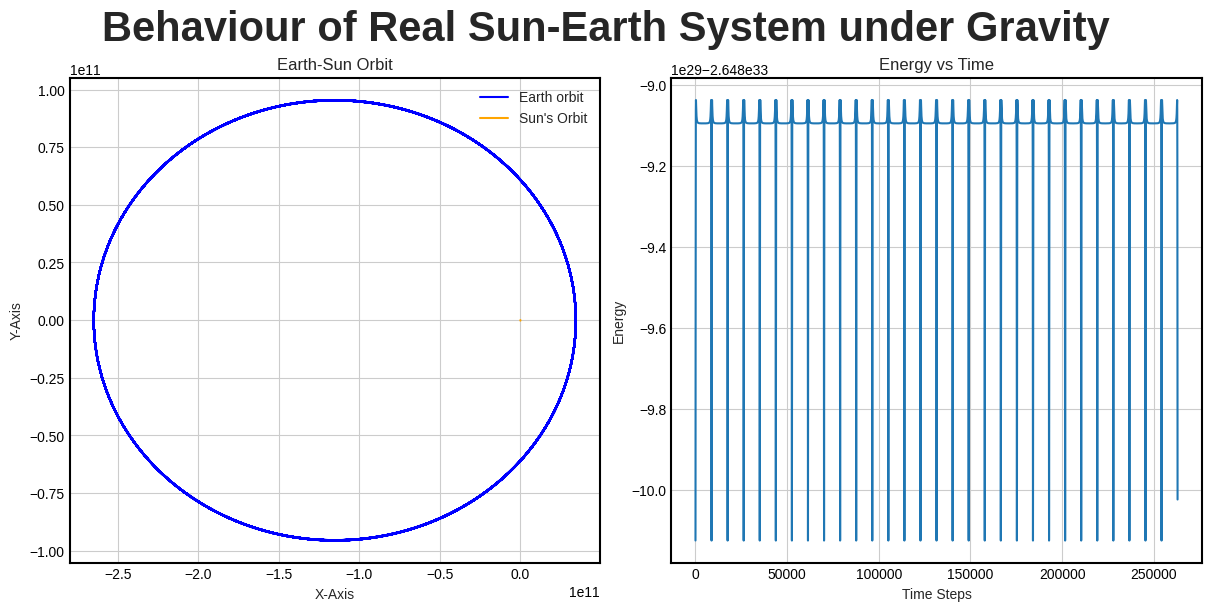

In [10]:
# Initial conditions
G = 6.67430e-11 # (N * m**2 /kg**2)
M = 1.9885e30 # kg(mass of the sun)
mE = 5.9722e24 #(mass of earth)
aE= 1.496e11 # meters( Length of semi major axis of Earth)
eE=0.77




# Earth's Orbital velocity and Position
v0E = np.sqrt(G *M* (1 + eE)/(aE*(1 - eE)))
vE = np.array([0.00,v0E]) #meters/sec
rE = np.array([aE*(1-eE),0.00])



# Sun's initial parametrs
rS =  np.array([0.00,0.00])
vS = -(mE*vE)/M
# Barycentric conditions
Rcm = (mE*rE ) / (M + mE )
Vcm = (mE*vE )/ (M + mE )
rS = -Rcm
rE = rE - Rcm
vS = vS - Vcm
vE = vE - Vcm
rES = rE - rS



positions = []
positions_S = []
energies =   []

dt = 3600 #1 hour
N = 30*int(365.25 * 24)

for x in range(N):

    aE = (-G*M*rES/np.linalg.norm(rES)**3)

    aS = (G*mE*(rES)/np.linalg.norm(rES)**3)

    vE_half = vE + 0.5 * dt * aE
    vS_half = vS + 0.5 * dt * aS

    rE = rE + dt*vE_half
    rS = rS + dt*vS_half
    rES = rE - rS


    aE_new =  (-G*M*rES/np.linalg.norm(rES)**3)
    aS_new = (G*mE*(rES)/np.linalg.norm(rES)**3)

    vE = vE_half + 0.5 * dt * aE_new

    vS = vS_half + 0.5 * dt * aS_new

    aE = aE_new

    aS = aS_new

    positions.append(rE.copy())

    positions_S.append(rS.copy())
    energy = ((0.5*M*np.dot(vS,vS) + 0.5 *mE*np.dot(vE,vE)) - (G*M*mE/np.linalg.norm(rE-rS)))
    energies.append(energy.copy())

positions = np.array(positions)
positions_S = np.array(positions_S)
energies = np.array(energies)

## Plotting
plt.style.use( 'seaborn-v0_8-whitegrid')


fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,6),constrained_layout=True)

ax[0].plot(positions[:,0],positions[:,1],color='blue',label='Earth orbit');

ax[0].plot(positions_S[:,0], positions_S[:,1], color = 'orange',label="Sun's Orbit")
ax[0].set(title='Earth-Sun Orbit',xlabel='X-Axis',ylabel='Y-Axis');



ax[0].legend(loc="upper right")

for spine in ax[0].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)

ax[0].tick_params(colors='#000000', width=1.2)

ax[1].plot(energies)
ax[1].set(title='Energy vs Time',xlabel='Time Steps',ylabel='Energy');
fig.suptitle('Behaviour of Real Sun-Earth System under Gravity', fontsize=30, fontweight='bold')
for spine in ax[1].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
ax[1].tick_params(colors='#000000', width=1.2)




# Case 3 : Letting eccentricity devolop naturally

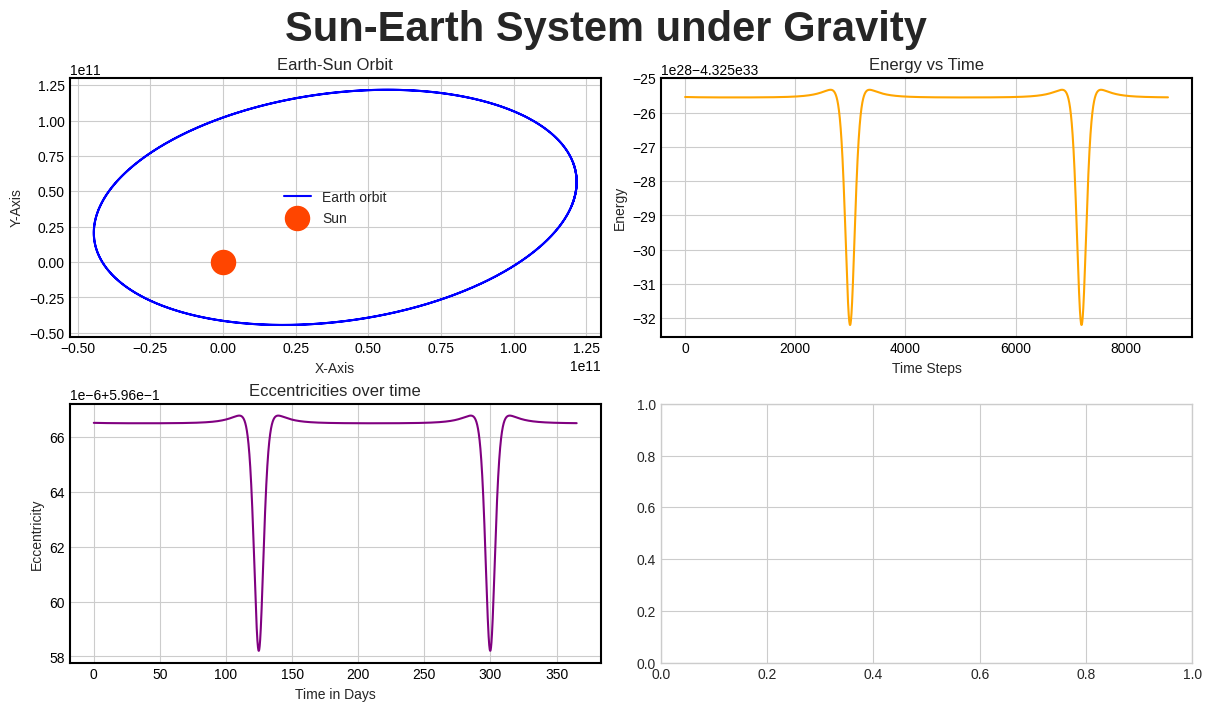

In [11]:

# Initial conditions
G = 6.67430e-11 # (N * m**2 /kg**2)
M_sun = 1.9885e30 # kg
mE = 5.9722e24 #(mass of earth)
a = 1.496e11 # meters


r =  np.array([1.2e11,0.4e11,0.00])
v = np.array([5e3,2.5e4,0.00])


def acceleration(r):
    r_mag = np.linalg.norm(r)
    return -G * M_sun * r / r_mag**3



positions = []

energies =   []

eccentricities = []

a =  acceleration(r)

#LeapFrog's methods

dt = 3600 # (1 hour)

N = int(365.25 * 24)   # hours in one year


for w in range(N):

    v_halfstep = v + 0.5 * dt * a

    r = r + dt*v_halfstep

    a_new = acceleration(r)

    v = v_halfstep + 0.5 * dt * a_new

    a = a_new

    h = np.cross(r, v)
    e_vec = np.cross(v, h)/(G*M_sun) - r/np.linalg.norm(r)
    e = np.linalg.norm(e_vec)
    eccentricities.append(e)

    positions.append(r.copy())
    energy = (0.5*mE*np.dot(v,v)) - G*M_sun*mE/np.linalg.norm(r)
    energies.append(energy.copy())

positions = np.array(positions)
energies = np.array(energies)

## Plotting
plt.style.use( 'seaborn-v0_8-whitegrid')


fig, ax = plt.subplots(nrows=2
                       ,ncols=2,figsize=(12,7),constrained_layout=True)

ax[0,0].plot(positions[:,0],positions[:,1],color='blue',label='Earth orbit');

ax[0,0].set(title='Earth-Sun Orbit',xlabel='X-Axis',ylabel='Y-Axis');

ax[0,0].scatter(0, 0,color='orangered',s=300,label='Sun',zorder=3);

ax[0,0].legend()

for spine in ax[0,0].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)

ax[0,0].tick_params(colors='#000000', width=1.2)


ax[0,1].plot(energies,color='orange')
ax[0,1].set(title='Energy vs Time',xlabel='Time Steps',ylabel='Energy');
for spine in ax[0,1].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
ax[0,1].tick_params(colors='#000000', width=1.2)

time = np.arange(N)*dt/(24*3600)

ax[1,0].plot(time,eccentricities,color='purple')
ax[1,0].set(title='Eccentricities over time',ylabel='Eccentricity',xlabel='Time in Days');
for spine in ax[1,0].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
ax[1,0].tick_params(colors='#000000', width=1.2)
fig.suptitle('Sun-Earth System under Gravity', fontsize=30, fontweight='bold');











## KEY OBSERVATIONS
##### 1. velocity of the planet varies along the orbit, the eccentricity remains constant because it depends on a conserved combination of position and velocity (the Laplace–Runge–Lenz vector), which is preserved under an inverse-square central force

# Plotting 3 body orbits (SUN-EARTH-JUPYTER SYSTEM)

## CASE 1 : Jupyter is moving in fixed circular orbit around the Sun

* Assumptions
1. sun at origin
2. force on jupyter due to earth is negligible
3. jupyter is not a dynamic system it follows a circular orbit around sun


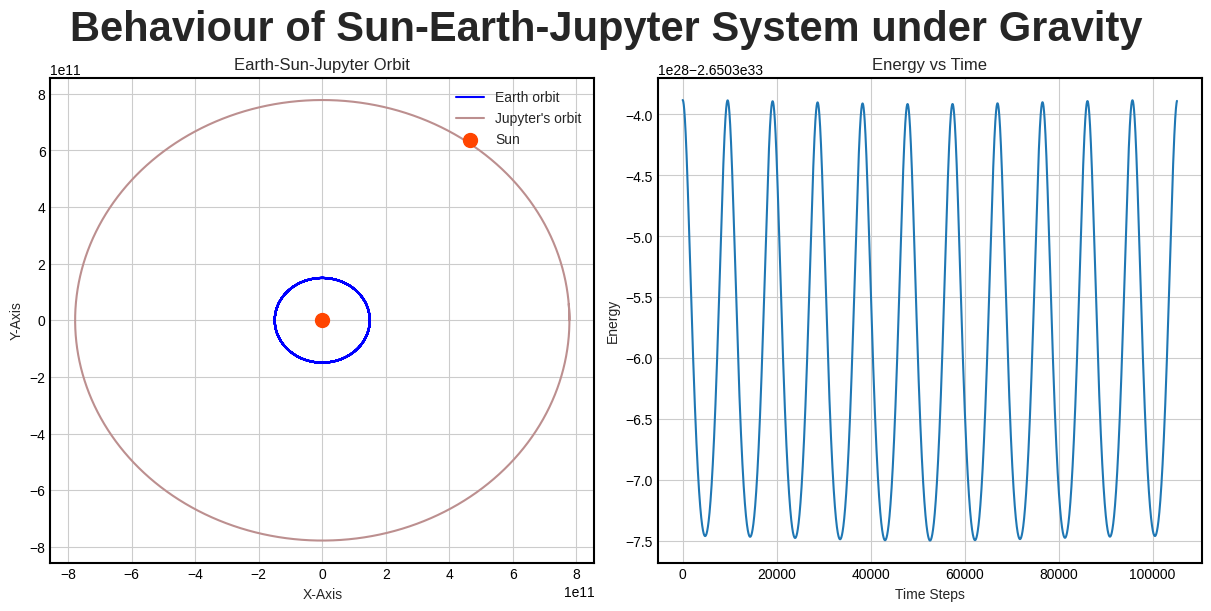

In [12]:
# Initial conditions
G = 6.67430e-11 # (N * m**2 /kg**2)
M = 1.9885e30 # kg(mass of the sun)
mE = 5.9722e24 #(mass of earth)
mJ = 1.898e27 #kg(mass of jupyter)

#Mean Orbital Radius of earth-sun system
r0 = 1.496e11 # meters
rE = np.array([r0,0.00])




# Earth's Orbital velocity
v0 = np.sqrt(G * M/ r0)
vE = np.array([0.00,v0]) #meters/sec

r0J= 7.78E11

omegaJ = np.sqrt(G*M/r0J**3)

positions = []
positions_J = []

energies =   []

dt = 3600 #1 hour
N = 12*int(365.25 * 24)

for x in range(N):

    t = x*dt

    rJ = np.array([r0J * np.cos(omegaJ * t), r0J * np.sin(omegaJ * t)])

    aE = (-G*M*rE/np.linalg.norm(rE)**3 - G*mJ*(rE-rJ)/np.linalg.norm(rE-rJ)**3)

    v_halfstep = vE + 0.5 * dt * aE

    rE = rE + dt*v_halfstep

    a_new =  (-G*M*rE/np.linalg.norm(rE)**3 - G*mJ*(rE-rJ)/np.linalg.norm(rE-rJ)**3)

    vE = v_halfstep + 0.5 * dt * a_new
    a = a_new

    positions.append(rE.copy())
    positions_J.append(rJ.copy())
    energy = (0.5 *mE*np.dot(vE,vE)) - (G*M*mE/np.linalg.norm(rE)) - (G*mE*mJ/np.linalg.norm(rE-rJ))
    energies.append(energy.copy())

positions = np.array(positions)
positions_J = np.array(positions_J)
energies = np.array(energies)

## Plotting
plt.style.use( 'seaborn-v0_8-whitegrid')


fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,6),constrained_layout=True)

ax[0].plot(positions[:,0],positions[:,1],color='blue',label='Earth orbit');
ax[0].plot(positions_J[:,0],positions_J[:,1], color= 'rosybrown',label="Jupyter's orbit");
ax[0].set(title='Earth-Sun-Jupyter Orbit',xlabel='X-Axis',ylabel='Y-Axis');

ax[0].scatter(0, 0,color='orangered',s=100,label='Sun',zorder=3);

ax[0].legend()

for spine in ax[0].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)

ax[0].tick_params(colors='#000000', width=1.2)

ax[1].plot(energies)
ax[1].set(title='Energy vs Time',xlabel='Time Steps',ylabel='Energy');
fig.suptitle('Behaviour of Sun-Earth-Jupyter System under Gravity', fontsize=30, fontweight='bold')
for spine in ax[1].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
ax[1].tick_params(colors='#000000', width=1.2)




# Case 2 : Real Dynamics of jupyter using leapfrog
* sun is still at centre and stationary
* energy is not conserved because

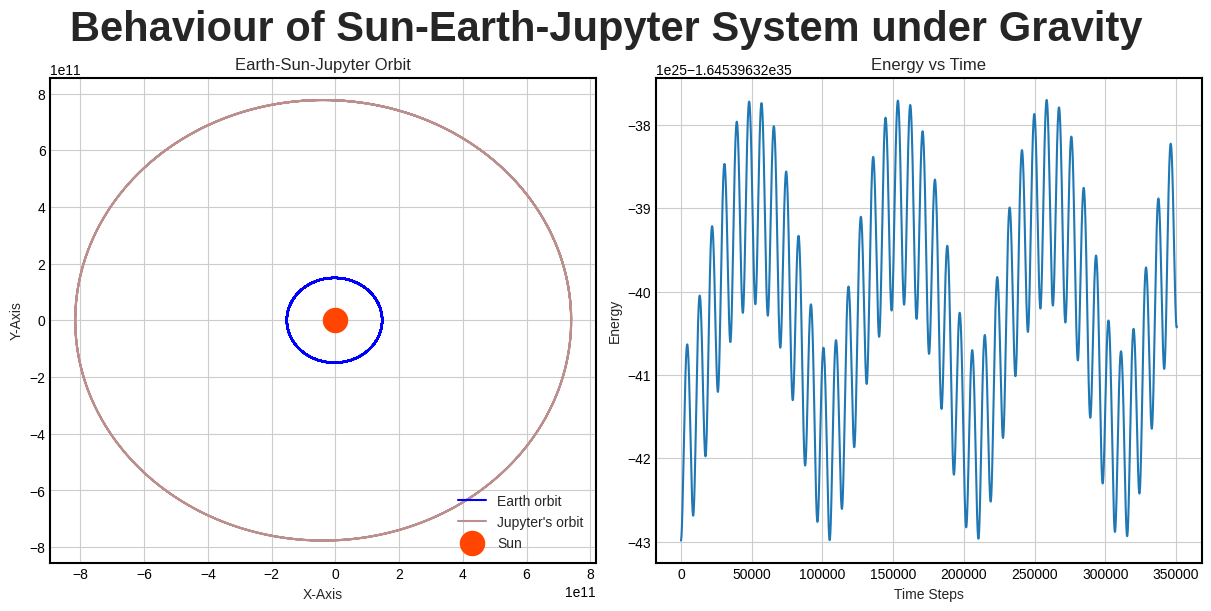

In [13]:
# Initial conditions
G = 6.67430e-11 # (N * m**2 /kg**2)
M = 1.9885e30 # kg(mass of the sun)
mE = 5.9722e24 #(mass of earth)
mJ = 1.898e27 #kg(mass of jupyter)
aE= 1.496e11 # meters( Length of semi major axis of Earth)
aJ= 7.78e11 #meters(Length of semi major axis of Jupyter)
eE =  0.0167
eJ = 0.0489




# Earth's Orbital velocity and Position
v0E = np.sqrt(G *M* (1 + eE)/(aE*(1 - eE)))
vE = np.array([0.00,v0E]) #meters/sec
rE = np.array([aE*(1-eE),0.00])

# Jupyter's Orbital velocity and Position
v0J = np.sqrt(G*M*(1+eJ)/(aJ*(1-eJ)))
vJ = np.array([0.00,v0J])
rJ = np.array([aJ*(1-eJ),0.00])




positions = []
positions_J = []

energies =   []

dt = 3600 #1 hour
N = 40*int(365.25 * 24)

for x in range(N):

    aJ = (-G*M*rJ/np.linalg.norm(rJ)**3 - G*mE*(rJ-rE)/np.linalg.norm(rJ-rE)**3)

    aE = (-G*M*rE/np.linalg.norm(rE)**3 - G*mJ*(rE-rJ)/np.linalg.norm(rE-rJ)**3)


    vE_half = vE + 0.5 * dt * aE
    vJ_half = vJ + 0.5 * dt * aJ

    rE = rE + dt*vE_half
    rJ = rJ + dt*vJ_half

    aE_new =  (-G*M*rE/np.linalg.norm(rE)**3 - G*mJ*(rE-rJ)/np.linalg.norm(rE-rJ)**3)
    aJ_new =  (-G*M*rJ/np.linalg.norm(rJ)**3 - G*mE*(rJ-rE)/np.linalg.norm(rJ-rE)**3)

    vE = vE_half + 0.5 * dt * aE_new
    vJ = vJ_half + 0.5*dt*aJ_new
    a_E = aE_new
    a_J = aJ_new

    positions.append(rE.copy())
    positions_J.append(rJ.copy())
    energy = ((0.5 *mE*np.dot(vE,vE)) + 0.5*mJ*np.dot(vJ,vJ) - (G*M*mE/np.linalg.norm(rE)) - (G*mE*mJ/np.linalg.norm(rE-rJ)) - (G*M*mJ/np.linalg.norm(rJ)))
    energies.append(energy.copy())

positions = np.array(positions)
positions_J = np.array(positions_J)
energies = np.array(energies)

## Plotting
plt.style.use( 'seaborn-v0_8-whitegrid')


fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,6),constrained_layout=True)

ax[0].plot(positions[:,0],positions[:,1],color='blue',label='Earth orbit');
ax[0].plot(positions_J[:,0],positions_J[:,1], color= 'rosybrown',label="Jupyter's orbit");
ax[0].set(title='Earth-Sun-Jupyter Orbit',xlabel='X-Axis',ylabel='Y-Axis');

ax[0].scatter(0, 0,color='orangered',s=300,label='Sun',zorder=3);

ax[0].legend()

for spine in ax[0].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)

ax[0].tick_params(colors='#000000', width=1.2)

ax[1].plot(energies)
ax[1].set(title='Energy vs Time',xlabel='Time Steps',ylabel='Energy');
fig.suptitle('Behaviour of Sun-Earth-Jupyter System under Gravity', fontsize=30, fontweight='bold')
for spine in ax[1].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
ax[1].tick_params(colors='#000000', width=1.2)




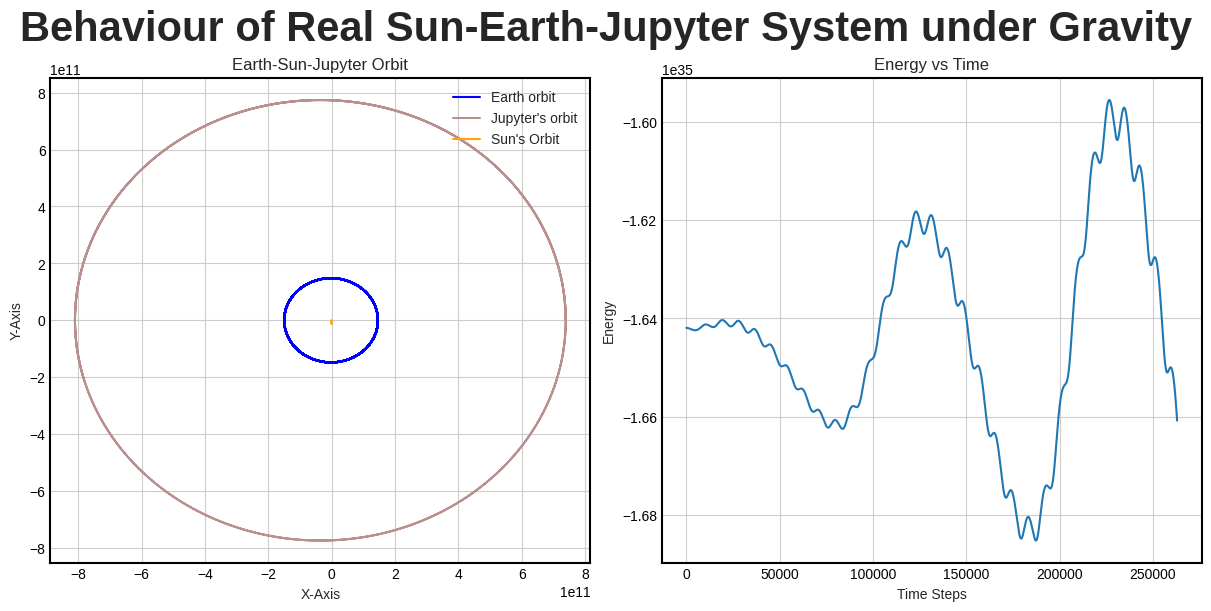

In [14]:
# Initial conditions
G = 6.67430e-11 # (N * m**2 /kg**2)
M = 1.9885e30 # kg(mass of the sun)
mE = 5.9722e24 #(mass of earth)
mJ = 1.898e27 #kg(mass of jupyter)
aE= 1.496e11 # meters( Length of semi major axis of Earth)
aJ= 7.78e11 #meters(Length of semi major axis of Jupyter)
eE =  0.0167
eJ = 0.0489




# Earth's Orbital velocity and Position
v0E = np.sqrt(G *M* (1 + eE)/(aE*(1 - eE)))
vE = np.array([0.00,v0E]) #meters/sec
rE = np.array([aE*(1-eE),0.00])

# Jupiter's Orbital velocity and Position
v0J = np.sqrt(G*M*(1+eJ)/(aJ*(1-eJ)))
vJ = np.array([0.00,v0J])
rJ = np.array([aJ*(1-eJ),0.00])

# Sun's initial parametrs
rS =  np.array([0.00,0.00])
vS = -(mE*vE+mJ*vJ)/M
# Barycentric conditions
Rcm = (mE*rE + mJ*rJ) / (M + mE + mJ)
Vcm = (mE*vE + mJ*vJ)/ (M + mE + mJ)
rS = -Rcm
rE = rE - Rcm
rJ = rJ - Rcm
vS = vS - Vcm
vE = vE - Vcm
vJ = vJ - Vcm




positions = []
positions_J = []
positions_S = []
energies =   []

dt = 3600 #1 hour
N = 30*int(365.25 * 24)

for x in range(N):

    aJ = (-G*M*rJ/np.linalg.norm(rJ)**3 - G*mE*(rJ-rE)/np.linalg.norm(rJ-rE)**3)

    aE = (-G*M*rE/np.linalg.norm(rE)**3 - G*mJ*(rE-rJ)/np.linalg.norm(rE-rJ)**3)

    aS = (-G*mE*(rS-rE)/np.linalg.norm(rS-rE)**3 - G*mJ*(rS-rJ)/np.linalg.norm(rS-rJ)**3)

    vE_half = vE + 0.5 * dt * aE
    vJ_half = vJ + 0.5 * dt * aJ
    vS_half = vS + 0.5 * dt * aS

    rE = rE + dt*vE_half
    rJ = rJ + dt*vJ_half
    rS = rS + dt*vS_half

    aE_new =  (-G*M*rE/np.linalg.norm(rE)**3 - G*mJ*(rE-rJ)/np.linalg.norm(rE-rJ)**3)
    aJ_new =  (-G*M*rJ/np.linalg.norm(rJ)**3 - G*mE*(rJ-rE)/np.linalg.norm(rJ-rE)**3)
    aS_new = (-G*mE*(rS-rE)/np.linalg.norm(rS-rE)**3 - G*mJ*(rS-rJ)/np.linalg.norm(rS-rJ)**3)

    vE = vE_half + 0.5 * dt * aE_new
    vJ = vJ_half + 0.5 * dt * aJ_new
    vS = vS_half + 0.5 * dt * aS_new

    aE = aE_new
    aJ = aJ_new
    aS = aS_new

    positions.append(rE.copy())
    positions_J.append(rJ.copy())
    positions_S.append(rS.copy())
    energy = ((0.5*M*np.dot(vS,vS) + 0.5 *mE*np.dot(vE,vE)) + 0.5*mJ*np.dot(vJ,vJ) - (G*M*mE/np.linalg.norm(rE-rS)) - (G*mE*mJ/np.linalg.norm(rE-rJ)) - (G*M*mJ/np.linalg.norm(rJ-rS)))
    energies.append(energy.copy())

positions = np.array(positions)
positions_J = np.array(positions_J)
positions_S = np.array(positions_S)
energies = np.array(energies)

## Plotting
plt.style.use( 'seaborn-v0_8-whitegrid')


fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,6),constrained_layout=True)

ax[0].plot(positions[:,0],positions[:,1],color='blue',label='Earth orbit');
ax[0].plot(positions_J[:,0],positions_J[:,1], color= 'rosybrown',label="Jupyter's orbit");
ax[0].plot(positions_S[:,0], positions_S[:,1], color = 'orange',label="Sun's Orbit")
ax[0].set(title='Earth-Sun-Jupyter Orbit',xlabel='X-Axis',ylabel='Y-Axis');



ax[0].legend(loc="upper right")

for spine in ax[0].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)

ax[0].tick_params(colors='#000000', width=1.2)

ax[1].plot(energies)
ax[1].set(title='Energy vs Time',xlabel='Time Steps',ylabel='Energy');
fig.suptitle('Behaviour of Real Sun-Earth-Jupyter System under Gravity', fontsize=30, fontweight='bold')
for spine in ax[1].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
ax[1].tick_params(colors='#000000', width=1.2)


